# RetailPulse – Inventory Optimization

## Objective

Use historical demand and demand forecasts to create inventory
planning recommendations.

## Business Questions

1. Which products have high demand?
2. Which products require closer inventory monitoring?
3. What is the expected future demand?
4. What should the reorder point be?
5. How much safety stock should be maintained?
6. Which products may require priority attention?

## Important Assumption

The source dataset does not contain actual inventory levels,
supplier lead times, purchase orders, or warehouse capacity.

Therefore, this analysis uses scenario-based assumptions for
demonstration purposes.

## Load Demand Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
FORECAST_DIR = Path("../data/forecast")

product_daily = pd.read_csv(
    FORECAST_DIR / "selected_product_daily_demand.csv"
)

forecast = pd.read_csv(
    FORECAST_DIR / "30_day_demand_forecast.csv"
)

print("Historical demand:", product_daily.shape)
print("Forecast:", forecast.shape)

Historical demand: (739, 3)
Forecast: (30, 5)


In [4]:
product_daily["InvoiceDate"] = pd.to_datetime(
    product_daily["InvoiceDate"],
    errors="coerce"
)

forecast["ds"] = pd.to_datetime(
    forecast["ds"],
    errors="coerce"
)

print("Dates converted successfully.")
print(product_daily["InvoiceDate"].dtype)
print(forecast["ds"].dtype)

Dates converted successfully.
datetime64[ns]
datetime64[ns]


In [5]:
print(product_daily.head())
print()
print(forecast.head())

  InvoiceDate  Quantity  Rolling_7D
0  2009-12-01        48         NaN
1  2009-12-02       435         NaN
2  2009-12-03        56         NaN
3  2009-12-04       144         NaN
4  2009-12-05        48         NaN

          ds        yhat  yhat_lower  yhat_upper  ForecastDemand
0 2011-11-10  478.200560  -41.428225  979.993823      478.200560
1 2011-11-11  336.175734 -130.869307  814.972084      336.175734
2 2011-11-12  172.483840 -299.724836  653.852615      172.483840
3 2011-11-13  230.113143 -273.743384  685.714171      230.113143
4 2011-11-14  292.675554 -161.143692  766.103792      292.675554


In [6]:
forecast.head(10)

,ds,yhat,yhat_lower,yhat_upper,ForecastDemand
0,2011-11-10,478.200560,-41.428225,979.993823,478.200560
1,2011-11-11,336.175734,-130.869307,814.972084,336.175734
2,2011-11-12,172.483840,-299.724836,653.852615,172.483840
3,2011-11-13,230.113143,-273.743384,685.714171,230.113143
4,2011-11-14,292.675554,-161.143692,766.103792,292.675554
5,2011-11-15,325.110044,-117.989716,819.911094,325.110044
6,2011-11-16,279.157415,-195.118657,773.597384,279.157415
7,2011-11-17,402.614705,-54.906903,923.911937,402.614705
8,2011-11-18,258.531104,-238.742735,764.813313,258.531104
9,2011-11-19,94.034207,-416.560235,569.179505,94.034207


## Calculate average daily demand

In [7]:
average_daily_demand = (
    forecast["ForecastDemand"].mean()
)

print(
    "Average forecasted daily demand:",
    round(average_daily_demand, 2)
)

Average forecasted daily demand: 221.69


## Calculate demand variability

In [8]:
historical_std = (
    product_daily["Quantity"].std()
)

print(
    "Historical daily demand standard deviation:",
    round(historical_std, 2)
)

Historical daily demand standard deviation: 383.04


## Scenario assumptions

In [9]:
LEAD_TIME_DAYS = 7
SERVICE_LEVEL_Z = 1.65

## Safety stock

In [10]:
safety_stock = (
    SERVICE_LEVEL_Z
    * historical_std
    * np.sqrt(LEAD_TIME_DAYS)
)

print(
    "Estimated safety stock:",
    round(safety_stock, 2)
)

Estimated safety stock: 1672.16


## Reorder point

In [11]:
lead_time_demand = (
    average_daily_demand
    * LEAD_TIME_DAYS
)

reorder_point = (
    lead_time_demand
    + safety_stock
)

print(
    "Lead-time demand:",
    round(lead_time_demand, 2)
)

print(
    "Safety stock:",
    round(safety_stock, 2)
)

print(
    "Recommended reorder point:",
    round(reorder_point, 2)
)

Lead-time demand: 1551.8
Safety stock: 1672.16
Recommended reorder point: 3223.96


## 30-day demand

In [12]:
forecast_30_day_demand = (
    forecast["ForecastDemand"].sum()
)

print(
    "Expected demand for next 30 days:",
    round(forecast_30_day_demand, 2)
)

Expected demand for next 30 days: 6650.58


## Inventory planning summary

In [13]:
inventory_summary = pd.DataFrame({
    "Metric": [
        "Average Daily Demand",
        "Lead Time (Days)",
        "Lead-Time Demand",
        "Historical Demand Std Dev",
        "Safety Stock",
        "Reorder Point",
        "Expected 30-Day Demand"
    ],
    
    "Value": [
        average_daily_demand,
        LEAD_TIME_DAYS,
        lead_time_demand,
        historical_std,
        safety_stock,
        reorder_point,
        forecast_30_day_demand
    ]
})

inventory_summary.round(2)

,Metric,Value
0,Average Daily Demand,221.69
1,Lead Time (Days),7.00
2,Lead-Time Demand,1551.80
3,Historical Demand Std Dev,383.04
4,Safety Stock,1672.16
5,Reorder Point,3223.96
6,Expected 30-Day Demand,6650.58


## Forecast visualization

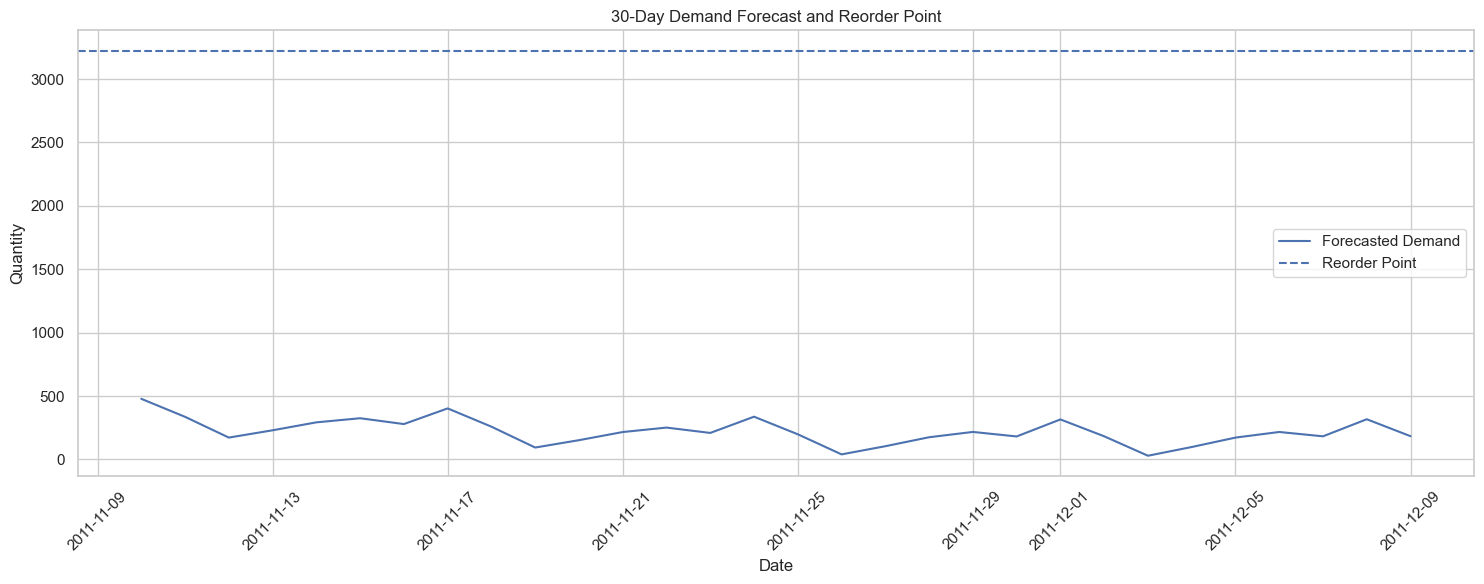

In [14]:
plt.figure(figsize=(15, 6))

plt.plot(
    forecast["ds"],
    forecast["ForecastDemand"],
    label="Forecasted Demand"
)

plt.axhline(
    reorder_point,
    linestyle="--",
    label="Reorder Point"
)

plt.title("30-Day Demand Forecast and Reorder Point")
plt.xlabel("Date")
plt.ylabel("Quantity")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Inventory recommendation

In [15]:
if average_daily_demand > 0:
    inventory_status = "High Priority"
else:
    inventory_status = "Review Required"

print(
    "Inventory planning status:",
    inventory_status
)

Inventory planning status: High Priority


## Scenario: current inventory

In [16]:
ASSUMED_CURRENT_STOCK = 1000

inventory_position = (
    ASSUMED_CURRENT_STOCK
    - forecast_30_day_demand
)

print(
    "Assumed current stock:",
    ASSUMED_CURRENT_STOCK
)

print(
    "Projected stock after 30 days:",
    round(inventory_position, 2)
)

Assumed current stock: 1000
Projected stock after 30 days: -5650.58


## Stock recommendation

In [17]:
if ASSUMED_CURRENT_STOCK <= reorder_point:
    recommendation = "Reorder immediately"
elif ASSUMED_CURRENT_STOCK <= reorder_point * 1.25:
    recommendation = "Monitor closely"
else:
    recommendation = "Stock level currently above reorder point"

print("Recommendation:", recommendation)

Recommendation: Reorder immediately


## Create inventory planning table

In [18]:
inventory_plan = pd.DataFrame({
    "Product": ["Selected Forecast Product"],
    "Average_Daily_Demand": [average_daily_demand],
    "Lead_Time_Days": [LEAD_TIME_DAYS],
    "Safety_Stock": [safety_stock],
    "Reorder_Point": [reorder_point],
    "Forecast_30_Day_Demand": [forecast_30_day_demand],
    "Assumed_Current_Stock": [ASSUMED_CURRENT_STOCK],
    "Projected_30_Day_Stock": [inventory_position],
    "Recommendation": [recommendation]
})

inventory_plan.round(2)

,Product,Average_Daily_Demand,Lead_Time_Days,Safety_Stock,Reorder_Point,Forecast_30_Day_Demand,Assumed_Current_Stock,Projected_30_Day_Stock,Recommendation
0,Selected Forecast Product,221.69,7,1672.16,3223.96,6650.58,1000,-5650.58,Reorder immediately


In [19]:
inventory_plan.to_csv(
    FORECAST_DIR / "inventory_planning.csv",
    index=False
)

inventory_summary.to_csv(
    FORECAST_DIR / "inventory_summary.csv",
    index=False
)

print("Inventory planning files saved successfully.")

Inventory planning files saved successfully.


# Inventory Optimization – Business Insights

## Demand

Historical transaction data was used to estimate future product demand.

## Safety Stock

Safety stock was estimated using historical demand variability and an
assumed supplier lead time.

## Reorder Point

The reorder point combines expected demand during the assumed lead time
with estimated safety stock.

## Business Recommendation

The forecast can support:

- Inventory monitoring
- Reorder planning
- Stockout prevention
- Safety-stock planning
- Demand-driven purchasing

## Limitation

Actual inventory optimization requires additional operational data,
including:

- Current inventory
- Supplier lead time
- Purchase orders
- Minimum order quantities
- Warehouse capacity
- Supplier reliability

Therefore, the current recommendation is a scenario-based analytical
model rather than a production inventory policy.